# ED408 — Statistical Machine Learning II Lab
## Experiment 1: k-Nearest Neighbours classifier from scratch
**Dataset:** Berkeley Segmentation Dataset (BSDS500) — boundary vs non-boundary pixel classification (17 local features; consensus human labels; train/test pixels from disjoint images).

*This notebook is standalone: it repeats the common data-loading step shared by all Module-I experiments. Requires `bsds_pixels.npz` (built by `extract_bsds.py`).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="deep")

D = np.load("bsds_pixels.npz", allow_pickle=True)
X_tr, y_tr = D["X_tr"].astype(float), D["y_tr"].astype(int)
X_te, y_te = D["X_te"].astype(float), D["y_te"].astype(int)
features = list(D["features"])

print("train:", X_tr.shape, " test:", X_te.shape)
print("boundary rate  train:", round(float(y_tr.mean()),4), " test:", round(float(y_te.mean()),4))
pd.DataFrame(X_tr, columns=features).describe().T.round(2)
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

train: (48000, 17)  test: (18000, 17)
boundary rate  train: 0.2667  test: 0.2667


## Data provenance (shared by all labs)

Pixels were sampled from **80 training images** and **30 test images** of BSDS500. Per image: up to 160 consensus-boundary pixels and 440 clear non-boundary pixels, with an 8-px border excluded to avoid filter edge artefacts. Feature extraction code: `extract_bsds.py` (included in the package; complete pipeline maintained on GitHub).

---
# Lab 1 — k-Nearest Neighbours **from scratch**

A fully vectorised implementation (no `sklearn.neighbors`). kNN is O(n·m) per query, so we work on a stratified subsample and study:
1. the effect of **feature scaling** (L runs 0–100 while a/b run ±60 and gradients 0–40 — unscaled distances are dominated by whichever filter happens to have the largest numeric range),
2. **k-selection** via a validation curve,
3. **distance-weighted voting** vs majority voting.

In [2]:
class KNNScratch:
    """Vectorised kNN with Euclidean distance and optional distance weighting."""
    def __init__(self, k=5, weighted=False):
        self.k, self.weighted = k, weighted

    def fit(self, X, y):
        self.X, self.y = np.asarray(X, float), np.asarray(y)
        return self

    def _dist(self, Q):
        # (q - x)^2 = q^2 - 2qx + x^2  -> full pairwise matrix without loops
        d2 = (Q**2).sum(1)[:, None] - 2 * Q @ self.X.T + (self.X**2).sum(1)[None, :]
        return np.sqrt(np.maximum(d2, 0))

    def predict_proba(self, Q, batch=1000):
        Q = np.asarray(Q, float)
        out = np.empty(len(Q))
        for s in range(0, len(Q), batch):
            D = self._dist(Q[s:s+batch])
            idx = np.argpartition(D, self.k, axis=1)[:, :self.k]
            labels = self.y[idx]
            if self.weighted:
                w = 1.0 / (np.take_along_axis(D, idx, 1) + 1e-9)
                out[s:s+batch] = (w * labels).sum(1) / w.sum(1)
            else:
                out[s:s+batch] = labels.mean(1)
        return out

    def predict(self, Q):
        return (self.predict_proba(Q) >= 0.5).astype(int)

def stratified_subsample(X, y, n, rng):
    idx = np.hstack([rng.choice(np.where(y==c)[0], int(n*(y==c).mean()), replace=False) for c in (0,1)])
    rng.shuffle(idx)
    return X[idx], y[idx]

Xs_tr, ys_tr = stratified_subsample(X_tr, y_tr, 6000, RNG)
Xs_te, ys_te = stratified_subsample(X_te, y_te, 2000, RNG)

# standardise using TRAIN statistics only
mu, sd = Xs_tr.mean(0), Xs_tr.std(0) + 1e-12
Z_tr, Z_te = (Xs_tr - mu)/sd, (Xs_te - mu)/sd

from sklearn.metrics import f1_score, accuracy_score
print("Unscaled  acc:", round(accuracy_score(ys_te, KNNScratch(15).fit(Xs_tr, ys_tr).predict(Xs_te)), 4))
print("Scaled    acc:", round(accuracy_score(ys_te, KNNScratch(15).fit(Z_tr,  ys_tr).predict(Z_te)), 4))

Unscaled  acc: 0.7834
Scaled    acc: 0.8089


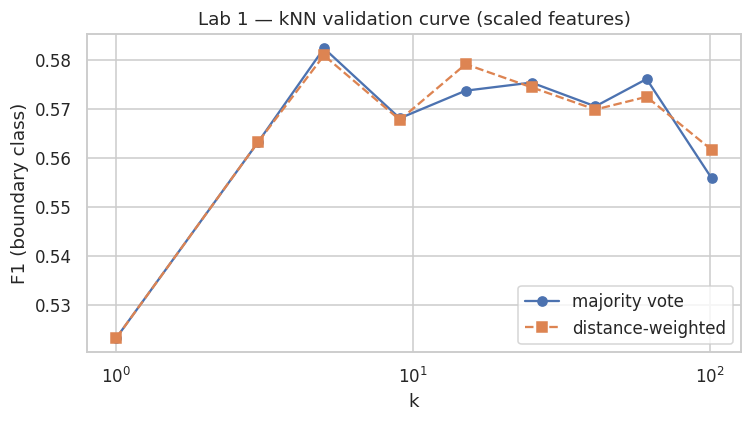

Best k=5: acc=0.7964, F1=0.5808


In [3]:
ks = [1, 3, 5, 9, 15, 25, 41, 61, 101]
res = {"plain": [], "weighted": []}
for k in ks:
    res["plain"].append(f1_score(ys_te, KNNScratch(k).fit(Z_tr, ys_tr).predict(Z_te)))
    res["weighted"].append(f1_score(ys_te, KNNScratch(k, weighted=True).fit(Z_tr, ys_tr).predict(Z_te)))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ks, res["plain"], "o-", label="majority vote")
ax.plot(ks, res["weighted"], "s--", label="distance-weighted")
ax.set(xlabel="k", ylabel="F1 (boundary class)", title="Lab 1 — kNN validation curve (scaled features)")
ax.set_xscale("log"); ax.legend(); plt.tight_layout(); plt.show()

best_k = ks[int(np.argmax(res["weighted"]))]
best = KNNScratch(best_k, weighted=True).fit(Z_tr, ys_tr)
pred = best.predict(Z_te)
print(f"Best k={best_k}: acc={accuracy_score(ys_te, pred):.4f}, F1={f1_score(ys_te, pred):.4f}")

**Observations.** Scaling changes the metric geometry: without it the L channel and large-σ filters dominate the distance. Boundary pixels *are* locally structured (an edge looks like an edge), so kNN performs far better here than on diffuse tabular problems — but it still misses low-contrast boundaries that humans mark from object knowledge rather than local evidence.